In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Part 1

In [11]:
!uv pip install ultralytics opencv-python
from ultralytics import YOLO
from ultralytics.solutions import VisionEye
import cv2
import numpy as np
from IPython.display import Video


Using Python 3.12.13 environment at: /usr
Checked 2 packages in 124ms


1. VisionEye detects objects, draws lines to detected objects and visualises it
2. it is good for secuirty, traffic control and in robotics
3. It draws a line from the viewpoint to the object unlike other models which detect it and thats all

Part 2

In [9]:
video_path = '/kaggle/input/datasets/edx409ahmedwael/ppl-walking/people walking.mp4'

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Could not open video")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print("VIDEO INFORMATION:")
    print(f"Width: {width} pixels")
    print(f"Height: {height} pixels")
    print(f"FPS: {fps} frames per second")
    print(f"Total Frames: {frame_count}")
    
    ret, frame = cap.read()
    if ret:
        print(f"\n Sample frame captured successfully")
    else:
        print("\n Could not read sample frame.")

cap.release()



VIDEO INFORMATION:
Width: 640 pixels
Height: 360 pixels
FPS: 25 frames per second
Total Frames: 341

 Sample frame captured successfully!


1. Lower resolution means detection will be more difficult object appears blurry small etc
2. frame size is needed to output the video with same desired resolution and frames so that the video does not output too fast/slow
3. poor lighting, low resolution, blurry

Part 3

In [16]:
model = YOLO(yolo26n.pt)

vision_point = (width//2, height//2)

vision = VisionEye(
    model=model,
    vision_point=vision,
    conf=0.25,
    show=True,
    line_width=2,
    classes=[0]
)

Ultralytics Solutions: ✅ {'source': None, 'model': YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, ep

In [25]:
# for some reason i have to put my variables again on the code section again
video_path = '/kaggle/input/datasets/edx409ahmedwael/ppl-walking/people walking.mp4'
cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

model = YOLO('yolo26n.pt')

vision_point = (width // 2, height // 2)

vision = VisionEye(
    model=model,
    vision_point=vision_point,
    conf=0.25,
    show=True,
    line_width=2,
    classes=[0]  # Only people
)

output_path = '/kaggle/working/visioneye_output.mp4'
out = cv2.VideoWriter(
    output_path,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

print(f"Output will be saved to: {output_path}")
frame_count = 0

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        print("End of video reached.")
        break
    
    frame_count += 1
    if frame_count % 30 == 0:
        print(f"Processing frame {frame_count}/{total_frames}")
    
    result = vision(frame)
    annotated_frame = result.plot_im
    out.write(annotated_frame)

cap.release()
out.release()

print(f"Frames processed: {frame_count}")
print(f"Output saved: {output_path}")

if os.path.exists(output_path):
    size = os.path.getsize(output_path) / (1024 * 1024)
    print(f"Output file created! Size: {size:.2f} MB")
else:
    print("Output file not found.")

Ultralytics Solutions: ✅ {'source': None, 'model': YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, ep

NameError: name 'os' is not defined

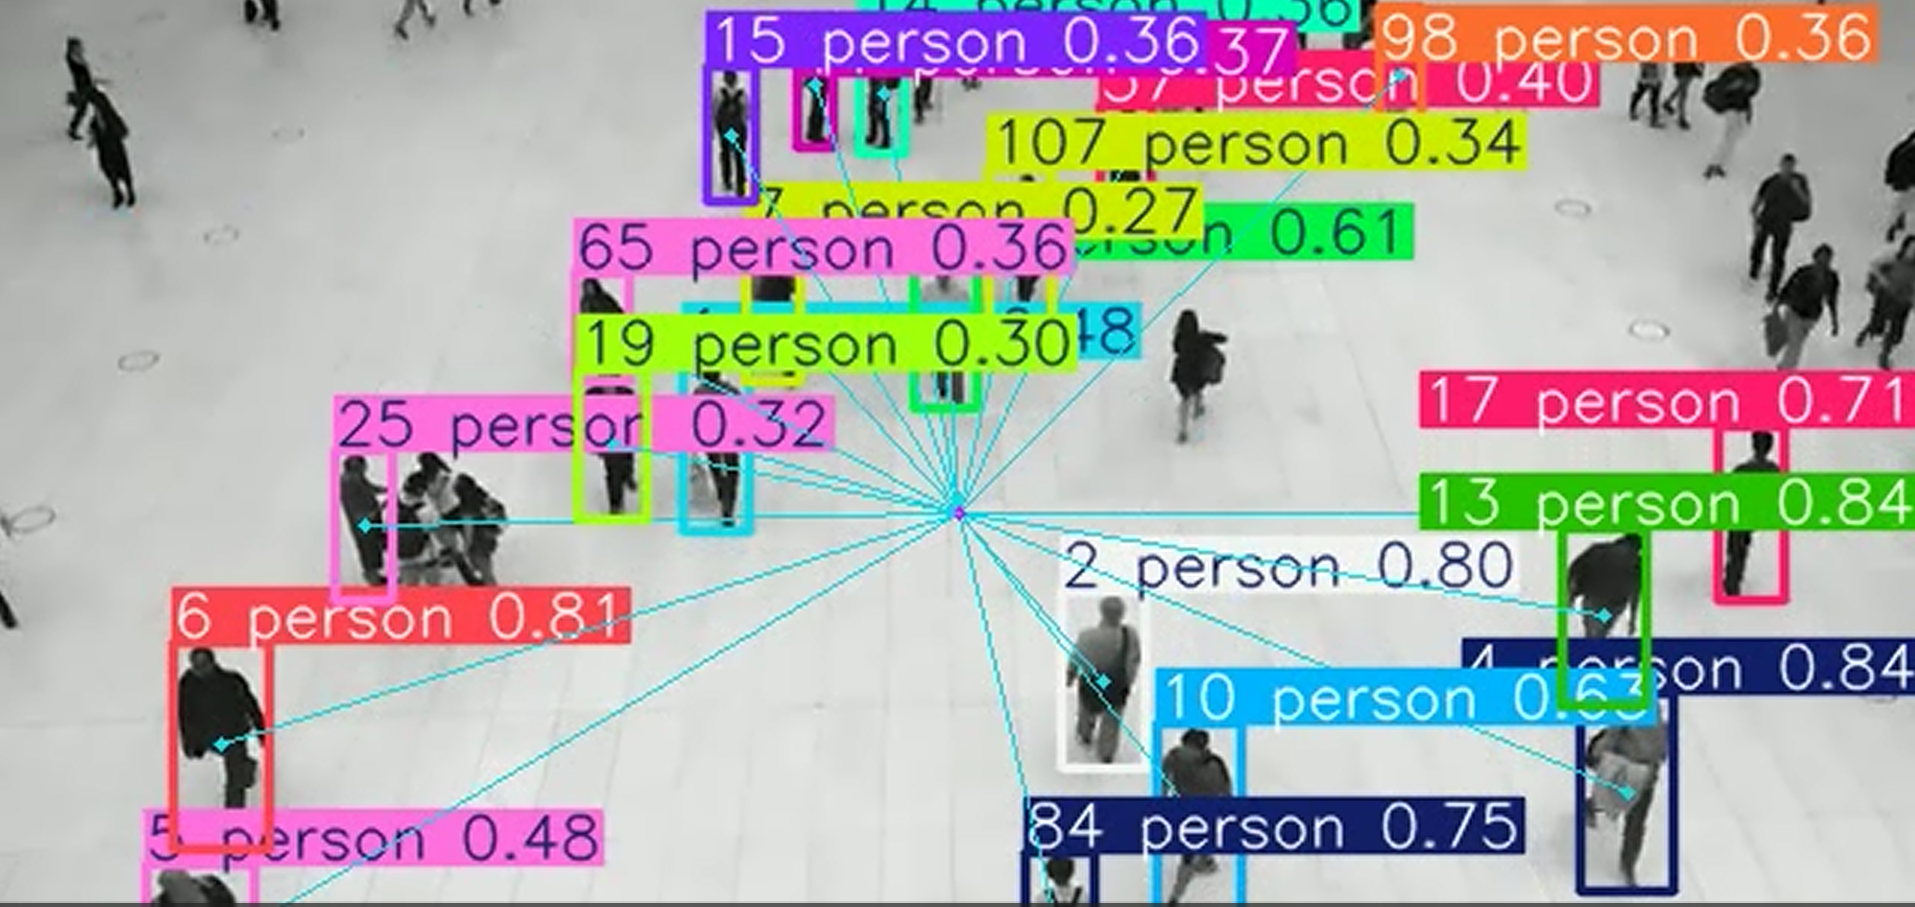